## Setup ##
load packages, initialize widgets, and set working directory
This step only needs to be run once

In [1]:
import numpy as np
import vtk
import vtkbone
from vtk.util.numpy_support import vtk_to_numpy

import pandas as pd
import SimpleITK as sitk

#ensure you have the helper_functions folder in your main directory
from helper_functions.vtk_util import vtkImageData_to_numpy, numpy_to_vtkImageData

import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

In [2]:
#plot widget feature
%matplotlib widget

# set the working directory to where the Jupyter notebook is currently located
%pwd  
%cd . 

/Users/daniellewhittier/Library/CloudStorage/OneDrive-UniversityofCalgary/Research/Osteobaddies


### Notebook Functions
These also only need to be run once

#### Step 1 Functions

In [3]:
def convert_to_numpy_and_sitk(image_input, spacing=None, origin=None):
    """
    Accept numpy array, vtkImageData, or SimpleITK image.

    Parameters
    ----------
    image_input : np.ndarray, vtk.vtkImageData, or sitk.Image
    spacing : tuple or None
        Optional spacing override in (x, y, z)
    origin : tuple or None
        Optional origin override in (x, y, z)

    Returns
    -------
    arr : np.ndarray
        Array in z, y, x order
    sitk_img : sitk.Image
    """
    # NumPy input
    if isinstance(image_input, np.ndarray):
        arr = image_input
        sitk_img = sitk.GetImageFromArray(arr)

        if spacing is not None:
            sitk_img.SetSpacing(tuple(spacing))
        if origin is not None:
            sitk_img.SetOrigin(tuple(origin))

        return arr, sitk_img

    # SimpleITK input
    if isinstance(image_input, sitk.Image):
        arr = sitk.GetArrayFromImage(image_input)
        return arr, image_input

    # VTK input
    try:
        import vtk
        from vtk.util.numpy_support import vtk_to_numpy
    except ImportError:
        vtk = None
        vtk_to_numpy = None

    if vtk is not None and isinstance(image_input, vtk.vtkImageData):
        dims_xyz = image_input.GetDimensions()
        vtk_spacing = tuple(image_input.GetSpacing())
        vtk_origin = tuple(image_input.GetOrigin())

        scalars = image_input.GetPointData().GetScalars()
        if scalars is None:
            raise ValueError("VTK image has no scalar data.")

        arr = vtk_to_numpy(scalars)

        # VTK x,y,z -> NumPy z,y,x
        arr = arr.reshape(dims_xyz, order="F")
        arr = np.transpose(arr, (2, 1, 0))

        sitk_img = sitk.GetImageFromArray(arr)

        sitk_img.SetSpacing(tuple(spacing) if spacing is not None else vtk_spacing)
        sitk_img.SetOrigin(tuple(origin) if origin is not None else vtk_origin)

        return arr, sitk_img

    raise TypeError("Input must be a numpy array, vtkImageData, or SimpleITK image.")

#### Step 2 Functions

In [4]:
def get_otsu_threshold(image):
    """
    Otsu threshold using SimpleITK, restricted to nonzero voxels.
    """
    mask = image > 0
    otsu_filter = sitk.OtsuThresholdImageFilter()
    otsu_filter.SetMaskValue(1)
    _ = otsu_filter.Execute(image, mask)
    return otsu_filter.GetThreshold()


def smooth_histogram(hist, window=7):
    """
    Simple moving-average smoothing.
    """
    if window <= 1:
        return hist.astype(float)

    kernel = np.ones(window, dtype=float) / window
    return np.convolve(hist, kernel, mode="same")


def find_local_peaks_1d(y, min_height=None, min_distance=5):
    """
    NumPy-based local peak finder.

    Parameters
    ----------
    y : 1D array
    min_height : float or None
    min_distance : int
        Minimum distance in bins between accepted peaks.

    Returns
    -------
    peaks : np.ndarray of indices
    """
    y = np.asarray(y)

    if y.ndim != 1 or len(y) < 3:
        return np.array([], dtype=int)

    peaks = np.where((y[1:-1] > y[:-2]) & (y[1:-1] >= y[2:]))[0] + 1

    if min_height is not None:
        peaks = peaks[y[peaks] >= min_height]

    if len(peaks) == 0:
        return peaks

    # Keep taller peaks first, then enforce spacing
    order = np.argsort(y[peaks])[::-1]
    selected = []

    for idx in peaks[order]:
        if all(abs(idx - s) >= min_distance for s in selected):
            selected.append(idx)

    selected = np.array(sorted(selected), dtype=int)
    return selected


def get_peak_threshold(
    vi_array,
    bins=500,
    smooth_window=7,
    min_peak_height_frac=0.01,
    min_peak_distance=8,
    ax=None,
    check_fit=False,
):
    """
    DoG fit.

    Strategy
    --------
    1. Build histogram of nonzero voxel intensities.
    2. Smooth histogram.
    3. Find local peaks.
    4. Take the highest-intensity meaningful peak.
    5. Walk left until the histogram drops to a fraction of the peak height.
       That location is used as the threshold.

    Returns
    -------
    peak_thresh : float
    debug : dict
    """
    vi_array = np.asarray(vi_array).ravel()
    if vi_array.size == 0:
        raise ValueError("Input intensity array is empty.")

    hist, bin_edges = np.histogram(
        vi_array,
        bins=bins,
        range=(np.min(vi_array), np.max(vi_array)),
    )
    bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2

    hist_smooth = smooth_histogram(hist, window=smooth_window)

    min_height = np.max(hist_smooth) * min_peak_height_frac
    peaks = find_local_peaks_1d(
        hist_smooth,
        min_height=min_height,
        min_distance=min_peak_distance,
    )

    if len(peaks) == 0:
        # fallback: use highest histogram bin
        peak_idx = int(np.argmax(hist_smooth))
    else:
        # choose the highest-intensity detected peak
        peak_idx = int(peaks[-1])

    peak_height = hist_smooth[peak_idx]

    # threshold at a fraction of the peak height on the left flank
    frac = 0.25
    left_idx = peak_idx
    while left_idx > 0 and hist_smooth[left_idx] > frac * peak_height:
        left_idx -= 1

    peak_thresh = bin_centres[left_idx]

    if check_fit and ax is not None:
        ax.plot(
            bin_centres,
            hist_smooth,
            "k-",
            linewidth=1.5,
            label="Smoothed histogram",
        )

        if len(peaks) > 0:
            ax.plot(
                bin_centres[peaks],
                hist_smooth[peaks],
                "x",
                color="orange",
                label="Detected peaks",
            )

        ax.axvline(
            bin_centres[peak_idx],
            color="gray",
            linestyle=":",
            linewidth=1.5,
            label=f"Chosen peak = {bin_centres[peak_idx]:.1f}",
        )

    debug = {
        "hist": hist,
        "hist_smooth": hist_smooth,
        "bin_edges": bin_edges,
        "bin_centres": bin_centres,
        "peaks": peaks,
        "chosen_peak_index": peak_idx,
    }

    return float(peak_thresh), debug


def create_hist(
    image_input,
    manual_threshold=0.0,
    check_fit=False,
    sample_size=None,
    bins=500,
    ignore_below=None,
    show=True,
):
    """
    Generate histogram and thresholds

    Parameters
    ----------
    image_input : numpy array, vtkImageData, or SimpleITK image
    manual_threshold : float
    check_fit : bool
    sample_size : int or None
        Randomly sample this many nonzero voxels for faster histogramming.
    bins : int
    ignore_below : float or None
        Ignore intensities below this value before histogramming.
        Useful for CT, e.g. ignore_below=-900.
    show : bool

    Returns
    -------
    results : dict
    fig, ax
    """
    image_array, sitk_img = convert_to_numpy_and_sitk(image_input)

    voxel_intensities = image_array.ravel()

    # remove zeros
    vi = voxel_intensities[voxel_intensities != 0]

    # optionally remove low background / air
    if ignore_below is not None:
        vi = vi[vi > ignore_below]

    if vi.size == 0:
        raise ValueError("No voxels remain after filtering.")

    # optional random subsampling for speed
    if sample_size is not None and vi.size > sample_size:
        rng = np.random.default_rng(42)
        vi = rng.choice(vi, size=sample_size, replace=False)

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.set_title("Histogram of Voxel Intensities")
    ax.set_xlabel("Voxel Intensity")
    ax.set_ylabel("Frequency")

    ax.hist(
        vi,
        bins=bins,
        range=(np.min(vi), np.max(vi)),
        color="blue",
        alpha=0.5,
        label="Histogram",
    )

    otsu_thresh = get_otsu_threshold(sitk_img)

    peak_thresh, debug = get_peak_threshold(
        vi,
        bins=bins,
        ax=ax,
        check_fit=check_fit,
    )

    ax.axvline(
        otsu_thresh,
        color="red",
        linestyle="dashed",
        linewidth=2,
        label=f"Otsu = {otsu_thresh:.1f}",
    )

    if manual_threshold != 0:
        ax.axvline(
            manual_threshold,
            color="green",
            linestyle="dashed",
            linewidth=2,
            label=f"Manual = {manual_threshold:.1f}",
        )

    ax.axvline(
        peak_thresh,
        color="purple",
        linestyle="dashed",
        linewidth=2,
        label=f"Peak-based = {peak_thresh:.1f}",
    )

    ax.legend(frameon=False)

    if show:
        plt.show()

    results = {
        "otsu_threshold": float(otsu_thresh),
        "manual_threshold": float(manual_threshold),
        "peak_threshold": float(peak_thresh),
        "n_voxels_used": int(vi.size),
    }

    return results, fig, ax, debug

#### Step 3A Functions

In [5]:
def voxel_sigma_to_physical_sigma(image, sigma_vox):
    """
    Convert Gaussian sigma from voxel units to physical units for SimpleITK.
    Assumes near-isotropic spacing.
    """
    spacing = np.array(image.GetSpacing(), dtype=float)
    return float(sigma_vox * np.mean(spacing))


def create_bone_mask(image, threshold, large_gaussian_kernel=10.0, max_intensity=None):
    """
    Create binary bone mask by blurring and thresholding.

    Parameters
    ----------
    image : sitk.Image
    threshold : float
    large_gaussian_kernel : float
        Gaussian sigma in VOXELS
    max_intensity : float or None
    """
    if max_intensity is None:
        max_intensity = float(sitk.GetArrayViewFromImage(image).max())

    threshold = float(threshold)
    max_intensity = float(max_intensity)

    sigma_physical = voxel_sigma_to_physical_sigma(image, large_gaussian_kernel)

    blurred = sitk.SmoothingRecursiveGaussian(
        image,
        sigma_physical,
    )

    bone_mask = sitk.BinaryThreshold(
        blurred,
        lowerThreshold=threshold,
        upperThreshold=max_intensity,
        insideValue=1,
        outsideValue=0,
    )

    return bone_mask


def isolate_lacuna_binary(
    image,
    bone_mask,
    threshold,
    small_gaussian_kernel=1.2,
    max_intensity=None,
):
    """
    Create binary image of isolated lacunae.

    Parameters
    ----------
    image : sitk.Image
    bone_mask : sitk.Image
    threshold : float
    small_gaussian_kernel : float
        Gaussian sigma in VOXELS
    max_intensity : float or None
    """
    if max_intensity is None:
        max_intensity = float(sitk.GetArrayViewFromImage(image).max())

    threshold = float(threshold)
    max_intensity = float(max_intensity)

    sigma_physical = voxel_sigma_to_physical_sigma(image, small_gaussian_kernel)

    inverted = sitk.InvertIntensity(image, maximum=max_intensity)

    smoothed = sitk.SmoothingRecursiveGaussian(
        inverted,
        sigma_physical,
    )

    inverted_threshold = float(max_intensity - threshold)

    masked = sitk.Mask(smoothed, bone_mask)

    binary_lacuna = sitk.BinaryThreshold(
        masked,
        lowerThreshold=inverted_threshold,
        upperThreshold=max_intensity,
        insideValue=1,
        outsideValue=0,
    )

    return binary_lacuna


def calculate_volume(binary_mask):
    """
    Calculate physical volume of a binary mask.
    """
    voxel_volume = float(np.prod(binary_mask.GetSpacing()))
    num_voxels = int(sitk.GetArrayViewFromImage(binary_mask).sum())
    return voxel_volume * num_voxels
    

def segment_lacunae(
    image_input,
    threshold,
    large_gaussian_kernel=10.0,
    small_gaussian_kernel=1.2,
    return_numpy=True,
):
    """
    Full notebook-friendly lacuna segmentation pipeline.

    Parameters
    ----------
    image_input : numpy.ndarray, vtk.vtkImageData, or sitk.Image
    threshold : float
        Threshold from Step 1
    large_gaussian_kernel : float
        Sigma in VOXELS for bone mask generation
    small_gaussian_kernel : float
        Sigma in VOXELS for lacuna smoothing after inversion
    return_numpy : bool
        Whether to return numpy arrays

    Returns
    -------
    results : dict
    """
    threshold = float(threshold)

    image_array, sitk_img = convert_to_numpy_and_sitk(image_input)
    max_intensity = float(image_array.max())

    bone_mask = create_bone_mask(
        sitk_img,
        threshold=threshold,
        large_gaussian_kernel=large_gaussian_kernel,
        max_intensity=max_intensity,
    )

    lacuna_binary = isolate_lacuna_binary(
        sitk_img,
        bone_mask=bone_mask,
        threshold=threshold,
        small_gaussian_kernel=small_gaussian_kernel,
        max_intensity=max_intensity,
    )

    bone_voxels = int(sitk.GetArrayViewFromImage(bone_mask).sum())
    lacuna_voxels = int(sitk.GetArrayViewFromImage(lacuna_binary).sum())

    results = {
        "input_sitk": sitk_img,
        "input_array": image_array,
        "bone_mask_sitk": bone_mask,
        "lacuna_binary_sitk": lacuna_binary,
        "threshold": threshold,
        "max_intensity": max_intensity,
        "inverted_threshold": float(max_intensity - threshold),
        "bone_voxels": bone_voxels,
        "lacuna_voxels": lacuna_voxels,
        "bone_volume": calculate_volume(bone_mask),
        "lacuna_volume": calculate_volume(lacuna_binary),
        "spacing": sitk_img.GetSpacing(),
    }

    if return_numpy:
        results["bone_mask_array"] = sitk.GetArrayFromImage(bone_mask)
        results["lacuna_binary_array"] = sitk.GetArrayFromImage(lacuna_binary)

    return results

In [6]:
def plot_lacuna_segmentation(results, slice_index=None, pmin=1, pmax=99):
    """
    Quick visualization of lacuna segmentation.

    Parameters
    ----------
    results : dict
        Output from segment_lacunae()
    slice_index : int or None
        z-slice to show; middle slice if None
    pmin, pmax : float
        Percentiles for grayscale display windowing
    """

    img = results["input_array"]

    if "bone_mask_array" in results:
        bone = results["bone_mask_array"]
    else:
        bone = sitk.GetArrayFromImage(results["bone_mask_sitk"])

    if "lacuna_binary_array" in results:
        lac = results["lacuna_binary_array"]
    else:
        lac = sitk.GetArrayFromImage(results["lacuna_binary_sitk"])

    if slice_index is None:
        slice_index = img.shape[0] // 2

    z = slice_index

    # robust grayscale display range
    vmin, vmax = np.percentile(img, [pmin, pmax])

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))

    axes[0].imshow(img[z], cmap="gray", vmin=vmin, vmax=vmax)
    axes[0].set_title(f"Original (z={z})")

    axes[1].imshow(bone[z], cmap="gray")
    axes[1].set_title("Bone mask")

    axes[2].imshow(lac[z], cmap="gray")
    axes[2].set_title("Lacuna binary")

    axes[3].imshow(img[z], cmap="gray", vmin=vmin, vmax=vmax)
    axes[3].imshow(np.ma.masked_where(lac[z] == 0, lac[z]), cmap="autumn", alpha=0.7)
    axes[3].set_title("Overlay")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

def browse_lacuna_segmentation(results, pmin=1, pmax=99):
    """
    Interactive z-slice browser for lacuna segmentation.
    """

    n_slices = results["input_array"].shape[0]

    interact(
        lambda z: plot_lacuna_segmentation(results, slice_index=z, pmin=pmin, pmax=pmax),
        z=IntSlider(min=0, max=n_slices - 1, step=1, value=n_slices // 2, description="z"),
    )

#### Step 3B Functions

In [7]:
def get_voxel_volume(image):
    """Return physical voxel volume in image spacing units cubed."""
    return float(np.prod(image.GetSpacing()))


def um3_to_image_volume(volume_um3, spacing_length_unit="mm"):
    """
    Convert a volume in um^3 to the image volume units implied by spacing.

    Examples
    --------
    spacing_length_unit='mm' -> returns mm^3
    spacing_length_unit='um' -> returns um^3
    """
    unit_to_mm = {
        "mm": 1.0,
        "um": 1e-3,
        "µm": 1e-3,
        "nm": 1e-6,
    }
    if spacing_length_unit not in unit_to_mm:
        raise ValueError(f"Unsupported spacing_length_unit: {spacing_length_unit}")

    mm_per_unit = unit_to_mm[spacing_length_unit]
    image_units_per_um = 1e-3 / mm_per_unit
    return float(volume_um3 * image_units_per_um**3)


def binary_array_to_sitk(binary_array, reference_image):
    """Convert a binary NumPy array to SimpleITK, preserving metadata."""
    out = sitk.GetImageFromArray(binary_array.astype(np.uint8))
    out.CopyInformation(reference_image)
    return out


def label_and_measure_components(binary_image):
    """
    Label connected components and return:
    - labeled SimpleITK image
    - labeled NumPy array
    - component table with label, voxel_count, and physical volume
    """
    labeled_image = sitk.ConnectedComponent(binary_image > 0)
    labeled_array = sitk.GetArrayFromImage(labeled_image)

    counts = np.bincount(labeled_array.ravel())
    voxel_volume = get_voxel_volume(binary_image)

    if len(counts) <= 1:
        table = pd.DataFrame(columns=["label", "voxel_count", "volume"])
        return labeled_image, labeled_array, table

    labels = np.arange(1, len(counts))
    voxel_counts = counts[1:]
    volumes = voxel_counts * voxel_volume

    table = pd.DataFrame({
        "label": labels.astype(int),
        "voxel_count": voxel_counts.astype(int),
        "volume": volumes.astype(float),
    })

    return labeled_image, labeled_array, table


def filter_component_table(component_table, lower_volume, upper_volume, voxel_volume):
    """
    Filter connected components by physical volume.
    Returns filtered table plus equivalent voxel thresholds.
    """
    lower_voxel_threshold = int(np.ceil(lower_volume / voxel_volume))
    upper_voxel_threshold = int(np.floor(upper_volume / voxel_volume))

    if component_table.empty:
        return component_table.copy(), lower_voxel_threshold, upper_voxel_threshold

    filtered = component_table[
        (component_table["volume"] >= lower_volume) &
        (component_table["volume"] <= upper_volume)
    ].copy()

    filtered = filtered.sort_values("voxel_count", ascending=False).reset_index(drop=True)
    return filtered, lower_voxel_threshold, upper_voxel_threshold


def build_filtered_binary(labeled_array, kept_labels):
    """Build a binary image containing only the selected connected-component labels."""
    if len(kept_labels) == 0:
        return np.zeros_like(labeled_array, dtype=np.uint8)

    keep = np.zeros(int(labeled_array.max()) + 1, dtype=bool)
    keep[np.asarray(kept_labels, dtype=int)] = True
    return keep[labeled_array].astype(np.uint8)


def summarize_lacuna_density(filtered_binary_image, bone_mask_image, component_table):
    """
    Summarize lacuna density statistics inside the bone mask.
    """
    voxel_volume = get_voxel_volume(filtered_binary_image)

    bone_voxels = int(sitk.GetArrayViewFromImage(bone_mask_image).sum())
    lacuna_voxels = int(sitk.GetArrayViewFromImage(filtered_binary_image).sum())

    bone_volume = bone_voxels * voxel_volume
    lacuna_volume = lacuna_voxels * voxel_volume
    n_lacunae = int(len(component_table))

    return {
        "n_lacunae": n_lacunae,
        "bone_voxels": bone_voxels,
        "lacuna_voxels": lacuna_voxels,
        "voxel_volume": float(voxel_volume),
        "bone_volume": float(bone_volume),
        "lacuna_volume": float(lacuna_volume),
        "mean_lacuna_volume": float(component_table["volume"].mean()) if n_lacunae > 0 else 0.0,
        "median_lacuna_volume": float(component_table["volume"].median()) if n_lacunae > 0 else 0.0,
        "lacuna_density_per_volume": float(n_lacunae / bone_volume) if bone_volume > 0 else 0.0,
        "lacuna_volume_fraction": float(lacuna_volume / bone_volume) if bone_volume > 0 else 0.0,
    }


def analyze_lacuna_density(
    lacuna_binary_input,
    bone_mask_input,
    lower_volume_um3=200.0,
    upper_volume_um3=1500.0,
    spacing_length_unit="mm",
    return_images=True,
):
    """
    Step 3: filter connected lacunae by size and compute density statistics.

    Parameters
    ----------
    lacuna_binary_input : np.ndarray, vtk image, or SimpleITK.Image
        Binary lacuna segmentation from Step 2.
    bone_mask_input : np.ndarray, vtk image, or SimpleITK.Image
        Binary bone mask from Step 2.
    lower_volume_um3 : float
        Lower lacuna volume threshold in um^3.
    upper_volume_um3 : float
        Upper lacuna volume threshold in um^3.
    spacing_length_unit : str
        Unit used by image spacing, usually "mm" or "um".
    return_images : bool
        Whether to return labeled and filtered images.

    Returns
    -------
    results : dict
    """
    _, lacuna_sitk = convert_to_numpy_and_sitk(lacuna_binary_input)
    _, bone_sitk = convert_to_numpy_and_sitk(bone_mask_input)

    voxel_volume = get_voxel_volume(lacuna_sitk)

    lower_volume = um3_to_image_volume(lower_volume_um3, spacing_length_unit)
    upper_volume = um3_to_image_volume(upper_volume_um3, spacing_length_unit)

    labeled_image, labeled_array, component_table = label_and_measure_components(lacuna_sitk)

    filtered_table, lower_voxel_threshold, upper_voxel_threshold = filter_component_table(
        component_table,
        lower_volume=lower_volume,
        upper_volume=upper_volume,
        voxel_volume=voxel_volume,
    )

    filtered_binary_array = build_filtered_binary(
        labeled_array,
        filtered_table["label"].to_numpy() if not filtered_table.empty else [],
    )

    filtered_binary_image = binary_array_to_sitk(filtered_binary_array, lacuna_sitk)

    summary = summarize_lacuna_density(
        filtered_binary_image=filtered_binary_image,
        bone_mask_image=bone_sitk,
        component_table=filtered_table,
    )

    if spacing_length_unit == "mm":
        summary["lacuna_density_per_mm3"] = summary["lacuna_density_per_volume"]
    else:
        unit_to_mm = {"mm": 1.0, "um": 1e-3, "µm": 1e-3, "nm": 1e-6}
        mm_per_unit = unit_to_mm[spacing_length_unit]
        summary["lacuna_density_per_mm3"] = summary["lacuna_density_per_volume"] / (mm_per_unit ** 3)

    results = {
        "summary": summary,
        "component_table": filtered_table,
        "lower_volume_um3": float(lower_volume_um3),
        "upper_volume_um3": float(upper_volume_um3),
        "lower_volume_image_units": float(lower_volume),
        "upper_volume_image_units": float(upper_volume),
        "lower_voxel_threshold": int(lower_voxel_threshold),
        "upper_voxel_threshold": int(upper_voxel_threshold),
        "spacing_length_unit": spacing_length_unit,
        "voxel_volume_image_units": float(voxel_volume),
    }

    if return_images:
        results["labeled_lacunae_sitk"] = labeled_image
        results["filtered_lacuna_binary_sitk"] = filtered_binary_image
        results["filtered_lacuna_binary_array"] = filtered_binary_array

    return results

In [8]:
def plot_filtered_lacunae(seg_results, density_results, slice_index=None, pmin=1, pmax=99):
    """
    Plot original image, bone mask, raw lacuna segmentation, and filtered lacunae.
    """
    img = seg_results["input_array"]

    bone = (
        seg_results["bone_mask_array"]
        if "bone_mask_array" in seg_results
        else sitk.GetArrayFromImage(seg_results["bone_mask_sitk"])
    )

    raw_lac = (
        seg_results["lacuna_binary_array"]
        if "lacuna_binary_array" in seg_results
        else sitk.GetArrayFromImage(seg_results["lacuna_binary_sitk"])
    )

    filt_lac = (
        density_results["filtered_lacuna_binary_array"]
        if "filtered_lacuna_binary_array" in density_results
        else sitk.GetArrayFromImage(density_results["filtered_lacuna_binary_sitk"])
    )

    if slice_index is None:
        slice_index = img.shape[0] // 2

    z = slice_index
    vmin, vmax = np.percentile(img, [pmin, pmax])

    fig, axes = plt.subplots(1, 5, figsize=(22, 5))

    axes[0].imshow(img[z], cmap="gray", vmin=vmin, vmax=vmax)
    axes[0].set_title(f"Original (z={z})")

    axes[1].imshow(bone[z], cmap="gray")
    axes[1].set_title("Bone mask")

    axes[2].imshow(raw_lac[z], cmap="gray")
    axes[2].set_title("Raw lacunae")

    axes[3].imshow(filt_lac[z], cmap="gray")
    axes[3].set_title("Filtered lacunae")

    axes[4].imshow(img[z], cmap="gray", vmin=vmin, vmax=vmax)
    axes[4].imshow(np.ma.masked_where(filt_lac[z] == 0, filt_lac[z]), cmap="autumn", alpha=0.7)
    axes[4].set_title("Filtered overlay")

    for ax in axes:
        ax.axis("off")

    fig.subplots_adjust(left=0.01, right=0.99, bottom=0.02, top=0.88, wspace=0.05)
    plt.show()


def browse_filtered_lacunae(seg_results, density_results, pmin=1, pmax=99):
    """
    Interactive slice browser for filtered lacunae.
    """
    n_slices = seg_results["input_array"].shape[0]

    interact(
        lambda z: plot_filtered_lacunae(
            seg_results,
            density_results,
            slice_index=z,
            pmin=pmin,
            pmax=pmax,
        ),
        z=IntSlider(
            min=0,
            max=n_slices - 1,
            step=1,
            value=n_slices // 2,
            description="z",
        ),
    )

##  Step 1: Select file and visualize to check

In [9]:
img_file = "input_lacunae_scans/f0000593.aim"

In [10]:
### read in bone aim image with vtkbone
reader = vtkbone.vtkboneAIMReader()
reader.DataOnCellsOff() 
reader.SetFileName(img_file)
reader.Update()
vtk_img_bone = reader.GetOutput()

#check dimension and image resolution of input image
print("input image dimensions [voxels]:", vtk_img_bone.GetDimensions())
print("input image resolution [mm]:", vtk_img_bone.GetSpacing())

input image dimensions [voxels]: (879, 901, 500)
input image resolution [mm]: (0.0020000000949949026, 0.0020000000949949026, 0.0020000000949949026)


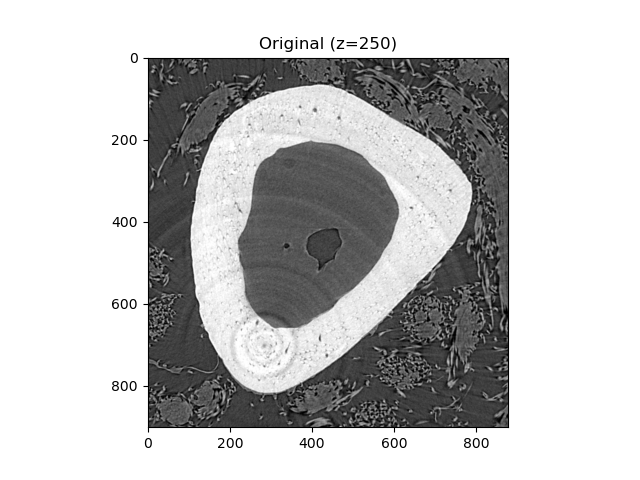

In [11]:
#read image and convert to different data formats
org_img, sitk_img = convert_to_numpy_and_sitk(vtk_img_bone)

#quick plot of input image

# slice is defined as middle slice, but this can be chnaged to a specific value
z = org_img.shape[0] // 2

# define grayscale display range
vmin, vmax = np.percentile(org_img, [1, 99])

plt.imshow(org_img[z], cmap="gray", vmin=vmin, vmax=vmax)
plt.title(f"Original (z={z})")
plt.show()

## Step 2: Determine sample-specific Threshold
This step is based on an adaptation of Goff et al. Bone 2021 (https://doi.org/10.1016/j.bone.2021.116094).
<br>The threshold selected is based on first finding the peaks in the histogram, then fitting a Gaussian distribution to the one that represents the bone tissue (assumed to be the highest-intensity peak, or right-most peak). The threshold is found by assuming a Gaussian fit to the peak and computing the first critical point (g′) of the curve.
<br> At the end of this step a visual output of the raw image histogram with the peaks identified, the chosen peak flagged, and the threhold local shown. The location of an alternative threshold obtained from the Ostu Method is also shown for interest sake. It can alternatively be used for lacunae segmentation, but it is not advised.

#### Cells to run the "find threshold" step
All the information shown in the plot is stored in the "results" output. This is called in the later cells for applying the threshold to the image

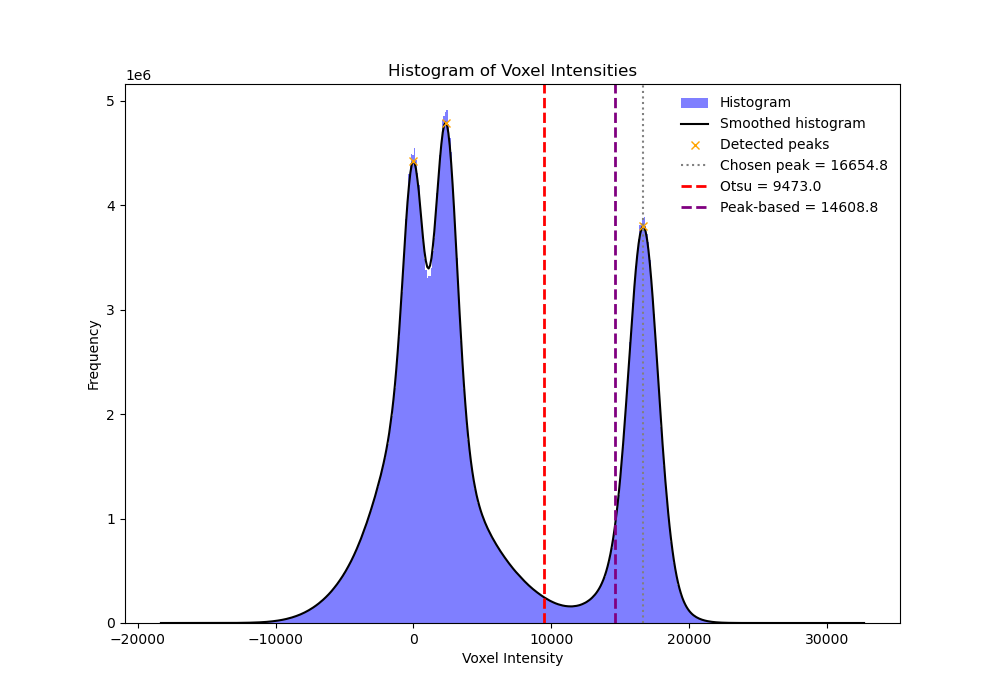

In [12]:
results, fig, ax, debug = create_hist(vtk_img_bone, check_fit=True)

In [13]:
#printed output of the threshold - currently this is in raw inensity units, so not meaningful outside this code
threshold = results["peak_threshold"]
print(results)

{'otsu_threshold': 9473.0, 'manual_threshold': 0.0, 'peak_threshold': 14608.75, 'n_voxels_used': 395945136}


## Step 3A: Segment lacunae
This step performes the following: 
1. Creates a mask of only the bone region using some morphological processes. 
2. Uses the threshold identified above to segment all voids within the masked bone region. This includes lacunae in addition to vessels, noise, and otherwise.
3. Provides a visual output of the intial segmentation - to be further filtered

#### Cells to run the step and visualize results:

In [14]:
seg_results = segment_lacunae(
    image_input=vtk_img_bone,
    threshold=threshold,
    return_numpy=True
)

print("Bone voxels:", seg_results["bone_voxels"])
print("Lacuna voxels:", seg_results["lacuna_voxels"])

Bone voxels: 93869280
Lacuna voxels: 4631455


In [15]:
#plot resultant mask and segmentation
browse_lacuna_segmentation(seg_results)

interactive(children=(IntSlider(value=250, description='z', max=499), Output()), _dom_classes=('widget-interac…

## Step 3B: Filter initial lacuna segmentation based on lacunae size
In the cell below specify the upper and lower thresholds for defining lacunae volume, in units of um^3

[cite work here where lacunae volume range is determined]

In [16]:
#specify the upper and lower volume cutoffs in um^3
lower_vol = 100
upper_vol = 1500

In [17]:
density_results = analyze_lacuna_density(
    lacuna_binary_input=seg_results["lacuna_binary_sitk"],
    bone_mask_input=seg_results["bone_mask_sitk"],
    lower_volume_um3=lower_vol,
    upper_volume_um3=upper_vol,
    spacing_length_unit="mm",
)

### Final output 
Shows the pipeline start to finish and provides summarizing metrics


In [18]:
browse_filtered_lacunae(seg_results, density_results)

interactive(children=(IntSlider(value=250, description='z', max=499), Output()), _dom_classes=('widget-interac…

In [19]:
density_results["summary"]

{'n_lacunae': 27649,
 'bone_voxels': 93869280,
 'lacuna_voxels': 1614247,
 'voxel_volume': 8.000001139938885e-09,
 'bone_volume': 0.7509543470052423,
 'lacuna_volume': 0.012913977840142926,
 'mean_lacuna_volume': 4.670685319593087e-07,
 'median_lacuna_volume': 3.760000535771276e-07,
 'lacuna_density_per_volume': 36818.48318777624,
 'lacuna_volume_fraction': 0.017196754891483135,
 'lacuna_density_per_mm3': 36818.48318777624}